In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv('data/split_by_element/ag10.csv')
df['YawState'].value_counts()

YawState
0.0    15836
Name: count, dtype: int64

In [3]:
df = pd.read_csv('data/split_by_element/ag10_daily_means_standard_normalized.csv')

COLUMNS_TO_DROP = [
    "GridPhase2Current",
    "GridPhase3Current",
    "BladeALockPitchAngle",
    "BladeBLockPitchAngle",
    "BladeCLockPitchAngle",
    "BladeCPitchBlockManOilPress",
    "GridPhase2Voltage",
    "GridPhase3Voltage",
    "GenCoolingWaterTankPress",
    "GearBearingHSSRotorEndTemperature",
    "GenPhase2Temperature",
    "GearHydrCoolingWaterLevel",
    "BladeBAverageLoad",
    "BladeCAverageLoad",
    "TrafoPhase2CoreTemperature",
    "TrafoPhase3CoreTemperature",
    "ReactivePowerSetPoint",
    "TrafoPhase3Temperature",
    "GridPhase1Current",
    "TotalQProduction",
    "GearBearingHSSGeneratorEndTemperature",
    "NacelleDirection",
    "GearHydrCoolingWaterTemperature",
    "ActivePowerExpected",
    "GearOilInletTemperature",
    "ControllerGroundTemperature",
    "TowerMaxAccY",
    "SpinnerTemperature",
    "RotorSpeed",
    "CapacityFactor",
    "HydraulicOilTemperature",
    "BrakeAccumulatorPress",
    "BladeCPitchBlockCylindPress",
    "WindSpeed",
    "GearBearingIMSFrontTemperature",
    "TrafoPhase2Temperature",
    "NacelleTemperature",
    "TrafoAuxTransformerTemperature",
]

df.drop(columns=[col for col in COLUMNS_TO_DROP if col in df.columns], inplace=True)
df.to_csv('data/split_by_element/ag10_daily_means_standard_normalized_reduced.csv', index=False)

In [12]:
# Load the data
df = pd.read_csv('data/split_by_element/ag02_daily_means.csv')

# Keep only numeric variables
# df = df.select_dtypes(include=[np.number])
# print(df.head())
# print(df.shape)
# print(df.dtypes)
# df[['ActivePower', 'BladeAAverageLoad', 'BladeAPitchBlockCylindPress', 'AmbientTemperature']].describe()
df['Cp'].sort_values(ascending=False).head(10)

7      5.322005
28     1.773710
142    1.244686
120    0.454394
122    0.399037
59     0.362422
134    0.360961
80     0.350414
84     0.335348
117    0.333810
Name: Cp, dtype: float64

In [17]:
df['AlarmCode']

0          NaN
1       2951.0
2       3273.0
3          NaN
4          NaN
         ...  
1086       NaN
1087    3272.0
1088       NaN
1089       NaN
1090       NaN
Name: AlarmCode, Length: 1091, dtype: float64

In [7]:
df2 = pd.read_csv('results/iterative_search_2_reduced/cluster_statistics_summary.csv')
# df2[['ActivePower_mean', 'BladeAAverageLoad_mean', 'BladeAPitchBlockCylindPress_mean', 'AmbientTemperature_mean']]
df2['Cp_mean']

0     0.273203
1     0.257068
2     0.266490
3     0.167759
4     7.431224
5     0.270575
6     0.266229
7     0.240759
8     0.267187
9     0.270403
10    0.217713
11    0.270527
12    0.232386
13    0.288482
14    0.183269
15    0.294433
16    0.280288
17    0.294603
18    0.275850
19    0.291400
20    1.694235
21    0.270481
22    0.306997
23    0.323430
24    0.288401
25    0.299379
26    0.268861
27    0.308589
28    0.289072
29    0.266089
30    0.254419
31    0.265180
32    0.259694
Name: Cp_mean, dtype: float64

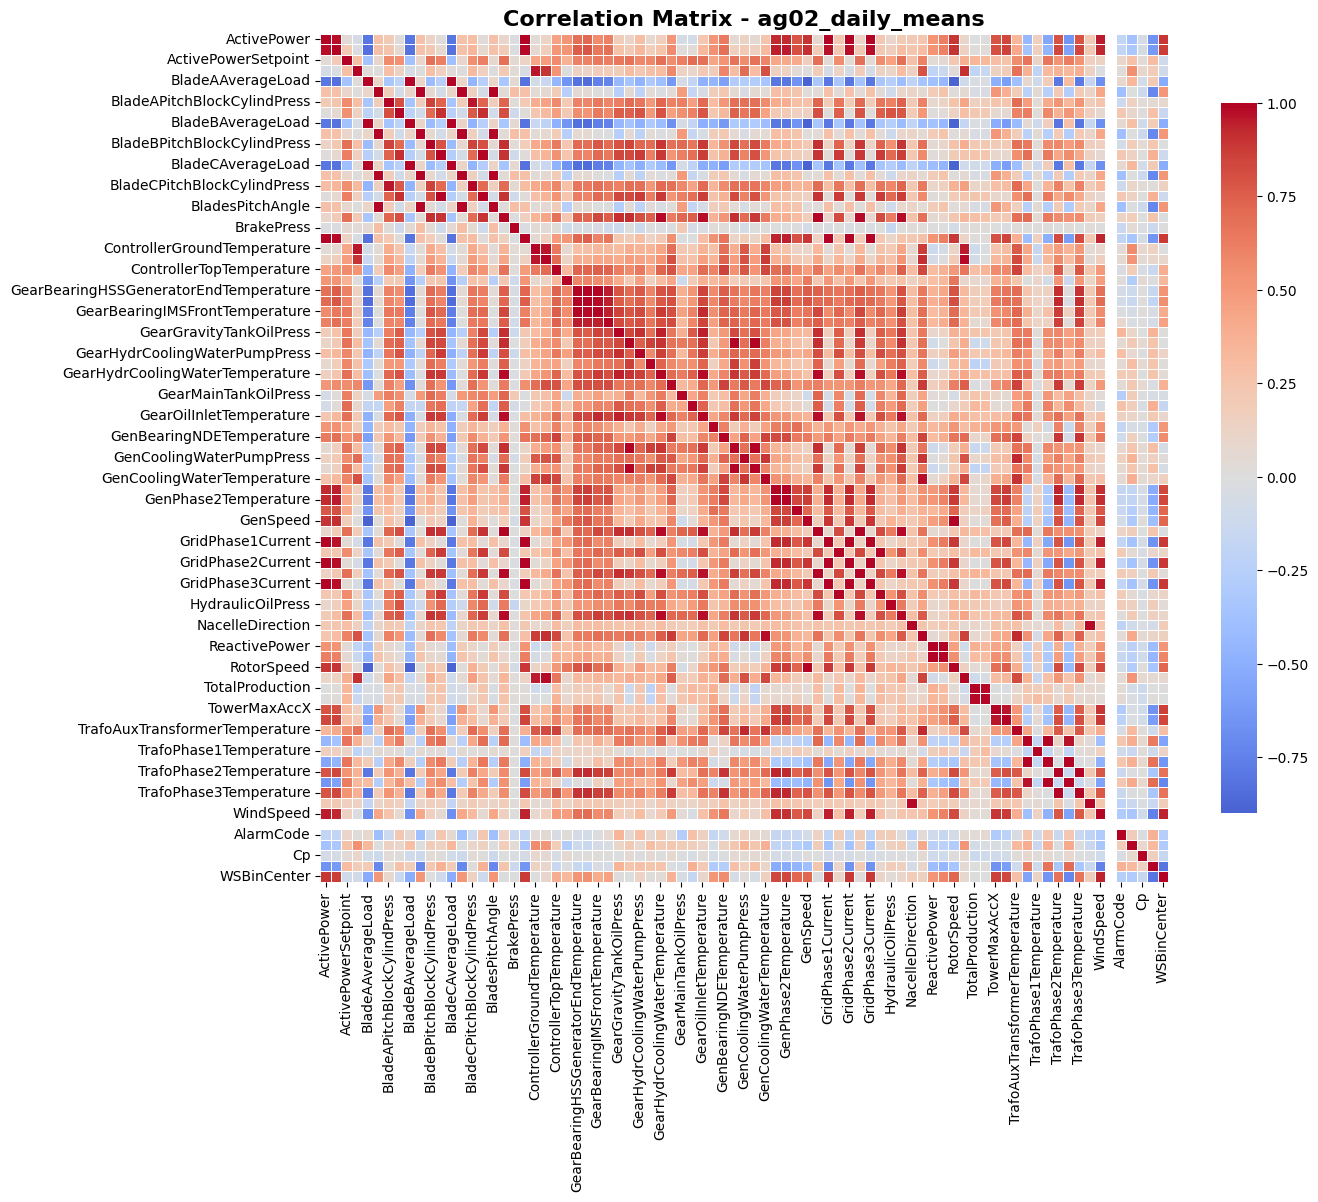

In [8]:
# Calculate correlation matrix and display as heatmap
plt.figure(figsize=(14, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - ag02_daily_means', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Get correlations with ActivePower and sort by absolute value
active_power_corr = correlation_matrix['ActivePower'].sort_values(ascending=False)
print("Features sorted by correlation with ActivePower:\n")
print(active_power_corr[-10:])

Features sorted by correlation with ActivePower:

AlarmCode                    -0.183994
TurbulenceIdx                -0.365079
TrafoPhase1CoreTemperature   -0.443655
TrafoPhase2CoreTemperature   -0.542618
TrafoPhase3CoreTemperature   -0.640592
TSR                          -0.657739
BladeBAverageLoad            -0.794511
BladeCAverageLoad            -0.797153
BladeAAverageLoad            -0.800675
YawState                           NaN
Name: ActivePower, dtype: float64


In [ ]:
seed = 11
folder = f"out_ag02_seed_{seed}"

df = pd.read_csv(f'results/{folder}/results/final_clustering_all_features.csv')
df.drop(columns=['row_index'], inplace=True)
df = df[df['cluster'] == 0]
df.to_csv(f'results/{folder}/results/final_clustering_no_cluster_0.csv', index=False)